# deepset + attn masks

## dataset modifications

In [1]:
from opas.data import *

In [2]:
B, m, n, d = 67, 17, 500, 226
torch.manual_seed(0)
q = torch.randn(m, d)
c = torch.randn(torch.randint(n//2,n,()), d)
print(c.shape)
pad_setting = [0 for _ in range(2*len(c.shape))]
pad_setting[-1] = n - c.shape[0]
print(F.pad(c, pad_setting).shape)

torch.Size([410, 226])
torch.Size([500, 226])


In [3]:
B, m, n, c, h, w = 67, 17, 500, 3, 32, 32
torch.manual_seed(0)
q = torch.randn(m, c, h, w)
c = torch.randn(torch.randint(n//2,n,()), c, h, w)
print(c.shape)
pad_setting = [0 for _ in range(2*len(c.shape))]
pad_setting[-1] = n - c.shape[0]
print(F.pad(c, pad_setting).shape)

torch.Size([471, 3, 32, 32])
torch.Size([500, 3, 32, 32])


In [4]:
dataset = PairDatasetTrainRandLen(filepath='final_data/audio/dataset_train.hdf5', nmax=500, num_q=300, negative_exploration=200)
test_dataset = PairDatasetTestRandlen(filepath='final_data/audio/dataset_test.hdf5', nmax=500)

In [5]:
dataset[0][0].shape, dataset[0][1].shape, dataset[0][2][:30], dataset[0][3]

(torch.Size([6, 4000]),
 torch.Size([500, 4000]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 0)

In [6]:
qpos, cpos, npos, l = dataset.get_positive_samples(num_samples=10)
qpos.shape, cpos.shape, npos.shape, l.shape

(torch.Size([10, 6, 4000]),
 torch.Size([10, 500, 4000]),
 torch.Size([10, 500]),
 torch.Size([10]))

In [9]:
test_dataset.c.shape, test_dataset.m_a.shape, test_dataset.m_a

((4864, 500, 4000),
 torch.Size([4864, 500]),
 tensor([[1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.]]))

## lammodel changes

In [1]:
import torch, torch.nn as nn

from opas.models.deepset import DeepSetLamModel, DeepSetwAttnMask
from opas.data import pad_corpus

In [4]:
B, m, n, d = 67, 17, 500, 226
torch.manual_seed(0)
q = torch.randn(B, m, d)
c = [pad_corpus(torch.randn(torch.randint(n//2,n,()), d), n) for _ in range(B)]
m_a = torch.stack([x[1] for x in c])
c = torch.stack([x[0] for x in c])
print(q.shape, c.shape, m_a.shape)

outdim = 128
deepset = DeepSetwAttnMask(indim=d, latent=64, outdim=outdim)
qq = deepset(q)
cc = deepset(c, m_a)
print(qq.shape, cc.shape)

model = DeepSetLamModel(indim=d, latent=64, outdim=outdim, m=6, share_deepset=False)
lambdas = model(q, c, m_a)
print(lambdas.shape)

torch.Size([67, 17, 226]) torch.Size([67, 500, 226]) torch.Size([67, 500])
torch.Size([67, 128]) torch.Size([67, 128])
torch.Size([67, 6])


In [7]:
lambdas[:10]

tensor([[0.0431, 1.0417, 0.3955, 0.0597, 0.2733, 0.4756],
        [0.0215, 1.0572, 0.3968, 0.0823, 0.2656, 0.4863],
        [0.0565, 1.0185, 0.3808, 0.0573, 0.2698, 0.4676],
        [0.0279, 1.0266, 0.4107, 0.0431, 0.2655, 0.4574],
        [0.0693, 1.0766, 0.4276, 0.0348, 0.2873, 0.4868],
        [0.0336, 1.0227, 0.3769, 0.0656, 0.2651, 0.4594],
        [0.0312, 1.0068, 0.3759, 0.0544, 0.2671, 0.4515],
        [0.0229, 1.0202, 0.3840, 0.0839, 0.2497, 0.4586],
        [0.0583, 1.0608, 0.4074, 0.0512, 0.2776, 0.4781],
        [0.0203, 1.0312, 0.4146, 0.1038, 0.2314, 0.4710]],
       grad_fn=<SliceBackward0>)

# ggez

## fwd pas simulation

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

from opas.utils import get_opas_constants, normalize
from opas.models.deepset import DeepSetModel

In [13]:
B, S, d = 67, 73, 226

out = torch.randn(B,S,d)
o1 = torch.einsum('bs,bsd->bd', torch.ones(B,S), out)
o2 = out.sum(dim=1)
o3 = (out * torch.ones(B,S,1)).sum(dim=1)

In [16]:
(o1 - o2).abs().max(), (o3 - o2).abs().max()

(tensor(1.1444e-05), tensor(0.))

In [2]:
import torch, numpy as np, matplotlib.pyplot as plt
from opas.utils import get_opas_constants, normalize

In [58]:
N = 29
m, nmax = 6, 500
d = 49
torch.manual_seed(0)
Q = normalize(torch.randn(m,d))
C = [normalize(torch.randn(torch.randint(nmax//2,nmax,(1,)),d)) for _ in range(N)]
Cp = torch.stack([torch.nn.functional.pad(c, (0,0,0,nmax-c.shape[0]), value=-float('inf')) for c in C])

In [64]:
qct = torch.einsum("md,Nnd->Nmn", Q, Cp)
qct[qct != qct] = -float('inf')
qct.softmax(dim=-1)[0][0][353:]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.])

# testing $A^{-T}(2QC^T - Y^T)$

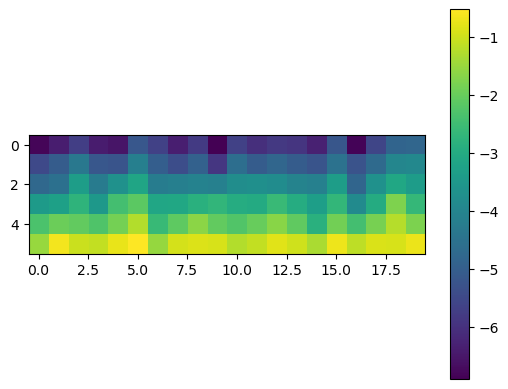

In [251]:
M, N = 6, 20
d = 49
Q = normalize(torch.randn(M,d))
C = normalize(torch.randn(N,d))
Y = torch.ones(N,M)

A, a, S = get_opas_constants(M, N, 'cpu')
A[0,0] = 1
plt.imshow((torch.linalg.inv(A.T) @ (2*Q@C.T - Y.T)))
plt.colorbar()

# degs

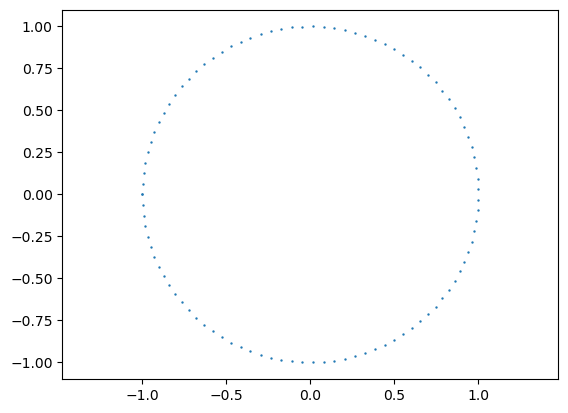

In [252]:
thetas = np.linspace(-np.pi,np.pi,100)

vals = [(np.cos(theta), np.sin(theta)) for theta in thetas]
plt.axis('equal')
plt.scatter(*zip(*vals), s=0.5)

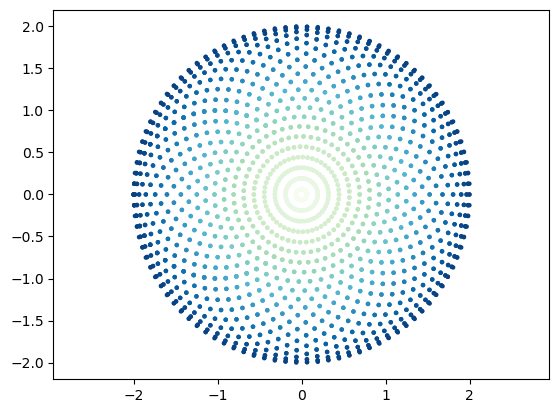

In [276]:
thetas = np.linspace(-np.pi,np.pi,50)

vals = [(np.cos(theta1)+np.cos(theta2), np.sin(theta1)+np.sin(theta2)) for theta1 in thetas for theta2 in thetas]
colors = [np.sqrt(x**2 + y**2) for x,y in vals]

plt.axis('equal')
plt.scatter(*zip(*vals), s=5, c=colors, cmap=plt.cm.GnBu)